# Spotify Data Analysis
# Project Objective
This project analyzes a Spotify dataset containing 8,582 songs.

The goal is to identify trends in:
- Song popularity
- Artist performance
- Music characteristics




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("spotify_data clean.csv", encoding="latin1")

## Dataset Overview

In [3]:
df.shape
df.head()
df.columns
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Track ID            8582 non-null   str    
 1   Track Name          8582 non-null   str    
 2   Track Number        8582 non-null   int64  
 3   Track Popularity    8582 non-null   int64  
 4   Explicit            8582 non-null   bool   
 5   Artist Name         8579 non-null   str    
 6   Artist Popularity   8582 non-null   int64  
 7    Artist Followers   8574 non-null   float64
 8   Artist Genres       5221 non-null   str    
 9   Album ID            8582 non-null   str    
 10  Album Name          8582 non-null   str    
 11  Album Release Date  8582 non-null   str    
 12  Album Total Tracks  8582 non-null   int64  
 13  Album Type          8582 non-null   str    
 14  Time Duration2      8582 non-null   str    
dtypes: bool(1), float64(1), int64(4), str(9)
memory usage: 947.2 KB


The dataset contains 8,582 songs and 15 variables.

Finding missing vaules

In [4]:
df.isnull().sum()

Track ID                 0
Track Name               0
Track Number             0
Track Popularity         0
Explicit                 0
Artist Name              3
Artist Popularity        0
 Artist Followers        8
Artist Genres         3361
Album ID                 0
Album Name               0
Album Release Date       0
Album Total Tracks       0
Album Type               0
Time Duration2           0
dtype: int64

## Findings 
- Artist Name contains misssing values.
- Artist Followers contains missing values.
- Artist Genres contains significant missing values.

Checking Duplicates

In [5]:
df.duplicated().sum()

np.int64(0)

# Question 1
What are the most popular songs?

In [6]:
top_songs = df.sort_values("Track Popularity", ascending=False).head(10)
top_songs


,Track ID,Track Name,Track Number,Track Popularity,Explicit,Artist Name,Artist Popularity,Artist Followers,Artist Genres,Album ID,Album Name,Album Release Date,Album Total Tracks,Album Type,Time Duration2
457,1CPZ5BxNNd0n0nF4Orb9JS,Golden,4,99,False,HUNTR/X,87,3551538.0,K-Pop,14JkAa6IiFaOh5s0nMyMU9,KPop Demon Hunters (Soundtrack from the Netfli...,6/20/2025,12,Album,3:14
88,3yWuTOYDztXjZxdE2cIRUa,Opalite,3,97,False,Taylor Swift,100,145443567.0,"Country, Pop, Indie, Folk",4a6NzYL1YHRUgx9e3YZI6I,The Life of a Showgirl,10/3/2025,12,Album,3:55
101,1jgTiNob5cVyXeJ3WgX5bL,Elizabeth Taylor,2,95,False,Taylor Swift,100,145489371.0,"Country, Pop, Indie, Folk",4a6NzYL1YHRUgx9e3YZI6I,The Life of a Showgirl,10/3/2025,12,Album,3:28
337,1qbmS6ep2hbBRaEZFpn7BX,Man I Need,1,95,False,Olivia Dean,88,1499215.0,Pop Soul,0Bv6OJO0L5gcf20DMww54a,Man I Need,8/15/2025,3,Single,3:04
103,03bTIHJElXZ0O0jqOQvAbY,Father Figure,4,94,True,Taylor Swift,100,145542136.0,"Country, Pop, Indie, Folk",4a6NzYL1YHRUgx9e3YZI6I,The Life of a Showgirl,10/3/2025,12,Album,3:32
1134,6dOtVTDdiauQNBQEDOtlAB,BIRDS OF A FEATHER,4,94,False,Billie Eilish,90,118692183.0,"Alternative Pop, Electropop, Dark Pop",7aJuG4TFXa2hmE4z1yxc3n,HIT ME HARD AND SOFT,5/17/2024,10,Album,3:30
450,02sy7FAs8dkDNYsHp4Ul3f,Soda Pop,3,94,False,Saja Boys,80,2234812.0,NaN,14JkAa6IiFaOh5s0nMyMU9,KPop Demon Hunters (Soundtrack from the Netfli...,6/20/2025,12,Album,2:31
460,1I37Zz2g3hk9eWxaNkj031,Your Idol,7,93,False,Saja Boys,80,2234812.0,NaN,14JkAa6IiFaOh5s0nMyMU9,KPop Demon Hunters (Soundtrack from the Netfli...,6/20/2025,12,Album,3:11
93,2x3mwb96B6TquRqMtbxUE1,Actually Romantic,7,93,True,Taylor Swift,100,145396321.0,"Country, Pop, Indie, Folk",4a6NzYL1YHRUgx9e3YZI6I,The Life of a Showgirl,10/3/2025,12,Album,2:43
97,5ylJtmaWPJ33cW3En7WOu0,Wood,9,93,True,Taylor Swift,100,145443567.0,"Country, Pop, Indie, Folk",4a6NzYL1YHRUgx9e3YZI6I,The Life of a Showgirl,10/3/2025,12,Album,2:30


Visualization


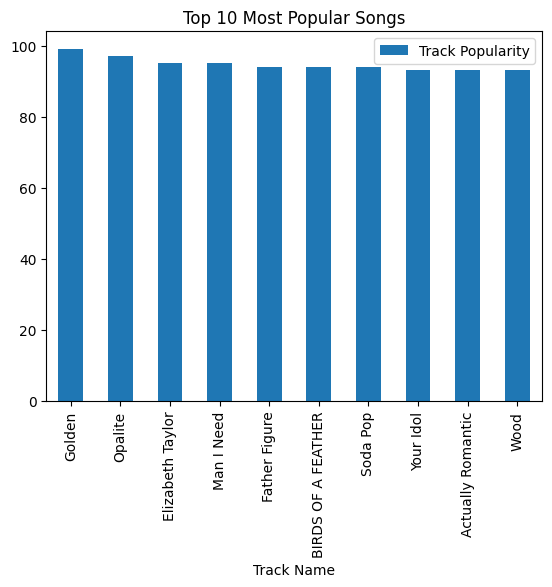

In [7]:
top_songs.plot.bar(x= "Track Name", y= "Track Popularity")
plt.title("Top 10 Most Popular Songs")
plt.show()

The most popular songs achieved the highest popularity scores in the dataset

# Question 2
Which artists are most popular?


In [8]:
top_artists = (df.groupby("Artist Name")["Artist Popularity"].mean().sort_values(ascending=False).head(10))
print(top_artists)

Artist Name
Taylor Swift         100.000000
Drake                 95.000000
Bad Bunny             95.000000
The Weeknd            93.326241
Justin Bieber         91.000000
Sabrina Carpenter     91.000000
Ariana Grande         90.000000
Rihanna               90.000000
Billie Eilish         90.000000
Bruno Mars            89.592593
Name: Artist Popularity, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

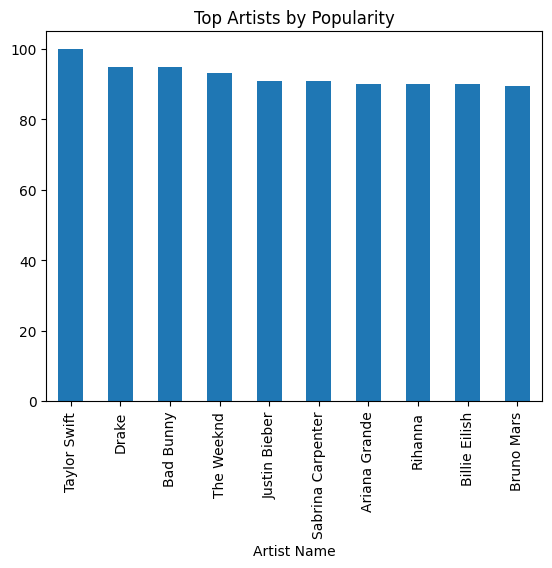

In [9]:
top_artists.plot.bar(x= "Artist Name", y= "Artist Popularity")
plt.title("Top Artists by Popularity")
plt.show

# Question 3
Which artists has the most followers?


In [10]:
df.columns = df.columns.str.strip()
top_followers = (df.groupby("Artist Name")["Artist Followers"].max().sort_values(ascending=False).head(10))
print(top_followers)


Artist Name
Taylor Swift     145542136.0
Ed Sheeran       122802777.0
Billie Eilish    118797451.0
The Weeknd       113039308.0
Ariana Grande    107418606.0
Eminem           104584370.0
Drake            103126025.0
Bad Bunny        102610644.0
Justin Bieber     85050158.0
BTS               81197976.0
Name: Artist Followers, dtype: float64


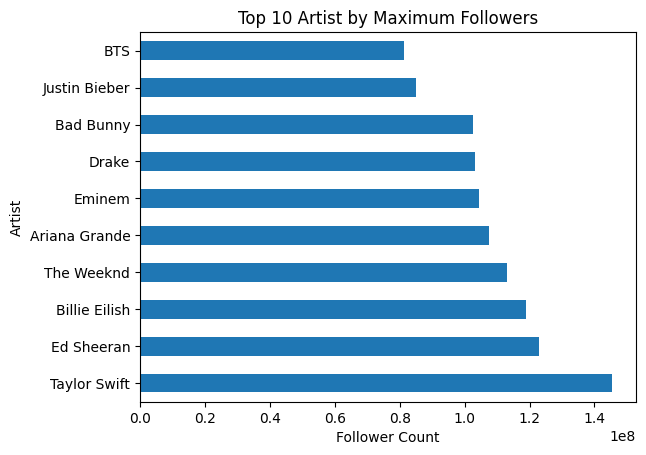

In [11]:
top_followers.plot.barh(x= "Artist Name", y= "Artist Followers")
plt.title("Top 10 Artist by Maximum Followers")
plt.xlabel("Follower Count")
plt.ylabel("Artist")
plt.show()

# Question 4
Are eplicit songs more popular?


In [12]:
df.groupby("Explicit")["Track Popularity"].mean()


Explicit
False    50.532639
True     57.818436
Name: Track Popularity, dtype: float64

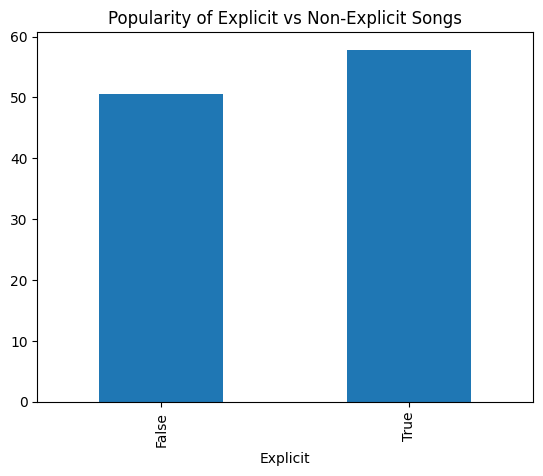

In [13]:
df.groupby("Explicit")["Track Popularity"].mean().plot(kind="bar")
plt.title("Popularity of Explicit vs Non-Explicit Songs")
plt.show()

# Question 5
Does follower count influence popularity?

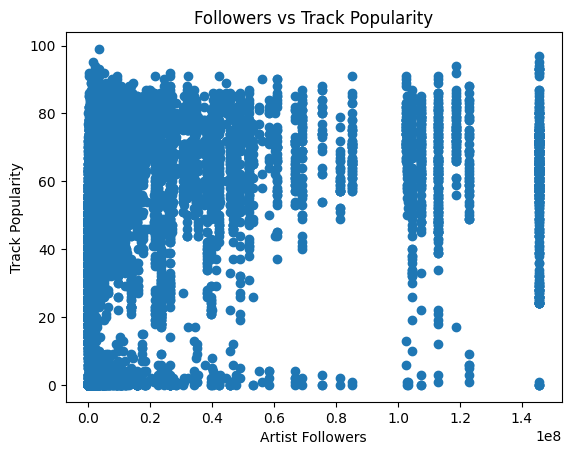

In [14]:
plt.scatter(df["Artist Followers"], df["Track Popularity"])
plt.xlabel("Artist Followers")
plt.ylabel("Track Popularity")
plt.title("Followers vs Track Popularity")
plt
plt.show()

The scatter plot suggests whether larger audiences are associated with higher track popularity.

# Question 6
Does song duration affect popularity?

In [15]:
df["Time Duration2"].head()

0    1:33
1    3:04
2    2:33
3    1:41
4    2:23
Name: Time Duration2, dtype: str

# Key Findings

1. The dataset contains over 8,500 Spotify tracks.
2. Several artists dominate popularity rankings.
3. Explicit and non-explicit songs show different popularity patterns.
4. Artist follower counts appear to influence popularity.
5. Song duration shows limited/moderate/strong relationship with popularity.